In [1]:
# Cell 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Cell 2 - Load Data
df = pd.read_csv('hospital_readmissions.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData Info:")
df.info()
print("\nTarget Distribution:")
print(df['readmitted'].value_counts())

Shape: (25000, 17)

First 5 rows:


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                25000 non-null  str  
 1   time_in_hospital   25000 non-null  int64
 2   n_lab_procedures   25000 non-null  int64
 3   n_procedures       25000 non-null  int64
 4   n_medications      25000 non-null  int64
 5   n_outpatient       25000 non-null  int64
 6   n_inpatient        25000 non-null  int64
 7   n_emergency        25000 non-null  int64
 8   medical_specialty  25000 non-null  str  
 9   diag_1             25000 non-null  str  
 10  diag_2             25000 non-null  str  
 11  diag_3             25000 non-null  str  
 12  glucose_test       25000 non-null  str  
 13  A1Ctest            25000 non-null  str  
 14  change             25000 non-null  str  
 15  diabetes_med       25000 non-null  str  
 16  readmitted         25000 non-null  str  
dtypes: int64(7)

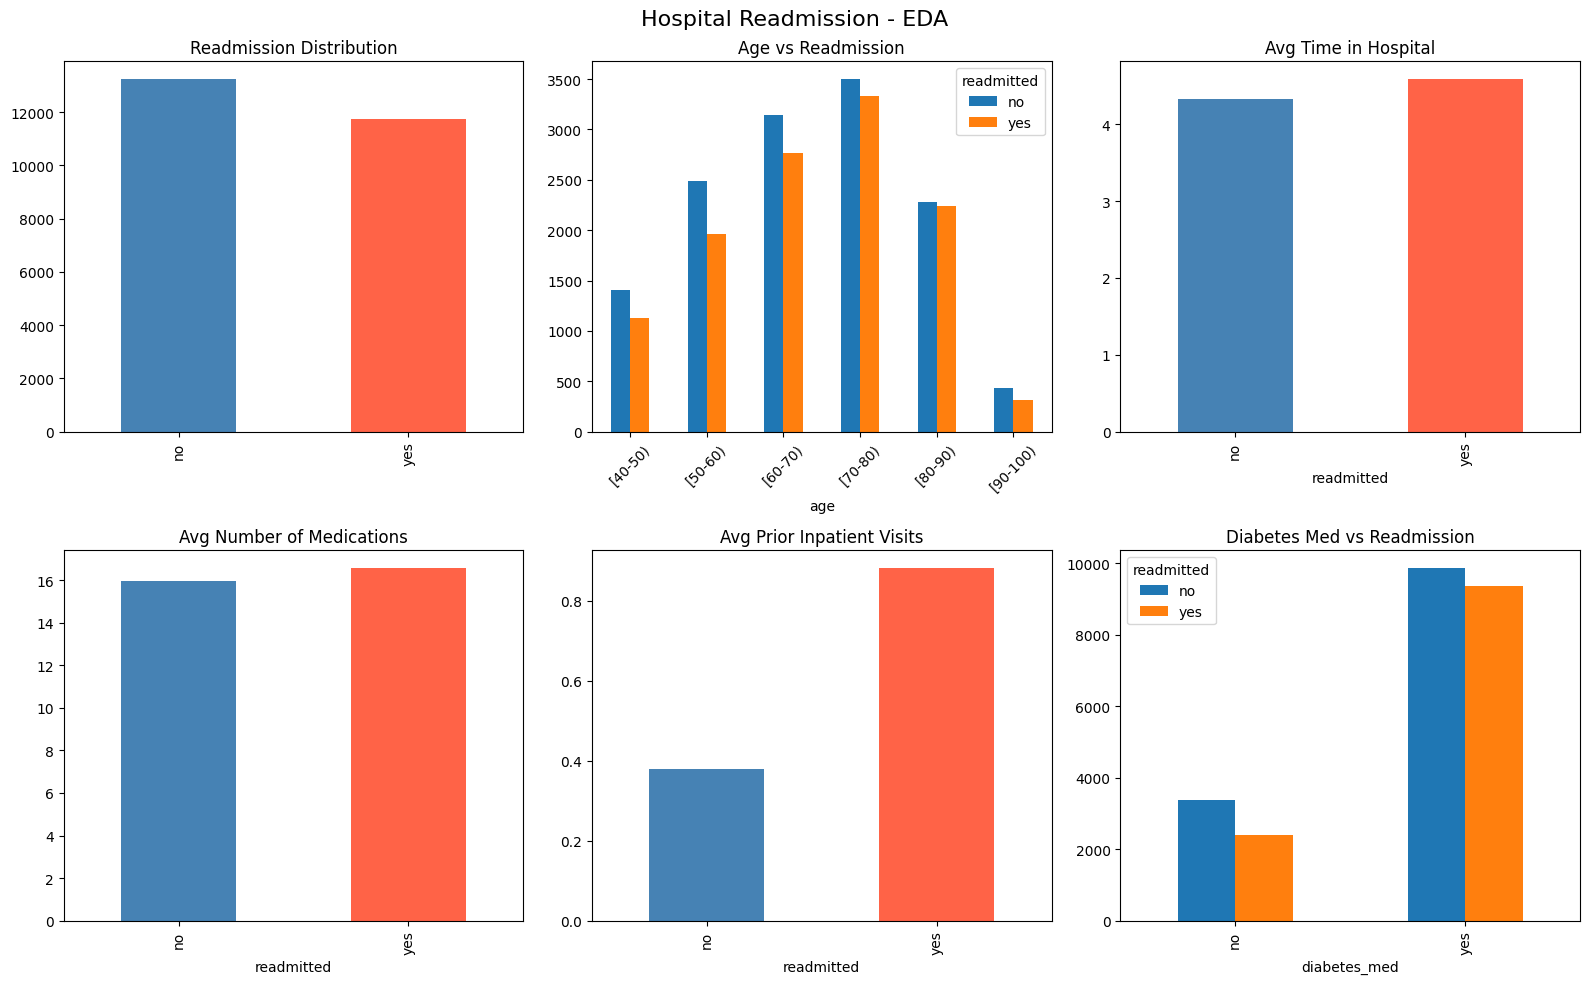

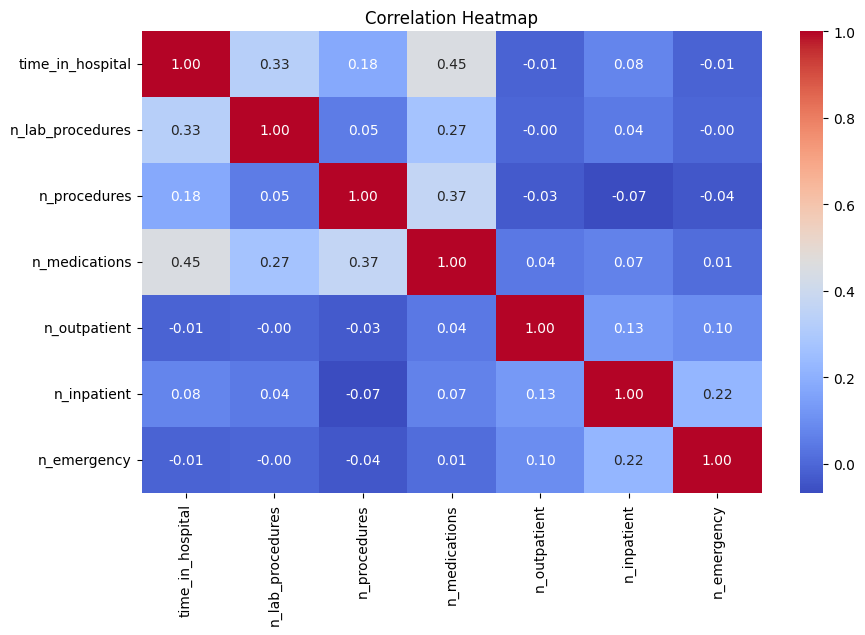

Key Observations:
Readmission Rate: 47.0%
Avg time in hospital (readmitted): 4.59
Avg time in hospital (not readmitted): 4.33


In [7]:
# Cell 3 - EDA

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Hospital Readmission - EDA', fontsize=16)

# 1. Target distribution
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Readmission Distribution')
axes[0,0].set_xlabel('')

# 2. Age vs Readmission
pd.crosstab(df['age'], df['readmitted']).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Age vs Readmission')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Time in hospital
df.groupby('readmitted')['time_in_hospital'].mean().plot(kind='bar', ax=axes[0,2], color=['steelblue','tomato'])
axes[0,2].set_title('Avg Time in Hospital')

# 4. Number of medications
df.groupby('readmitted')['n_medications'].mean().plot(kind='bar', ax=axes[1,0], color=['steelblue','tomato'])
axes[1,0].set_title('Avg Number of Medications')

# 5. Inpatient visits
df.groupby('readmitted')['n_inpatient'].mean().plot(kind='bar', ax=axes[1,1], color=['steelblue','tomato'])
axes[1,1].set_title('Avg Prior Inpatient Visits')

# 6. Diabetes med vs readmission
pd.crosstab(df['diabetes_med'], df['readmitted']).plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Diabetes Med vs Readmission')

plt.tight_layout()
plt.show()

# Correlation heatmap for numeric columns
plt.figure(figsize=(10, 6))
numeric_cols = ['time_in_hospital','n_lab_procedures','n_procedures',
                'n_medications','n_outpatient','n_inpatient','n_emergency']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

print("Key Observations:")
print(f"Readmission Rate: {(df['readmitted']=='yes').mean()*100:.1f}%")
print(f"Avg time in hospital (readmitted): {df[df['readmitted']=='yes']['time_in_hospital'].mean():.2f}")
print(f"Avg time in hospital (not readmitted): {df[df['readmitted']=='no']['time_in_hospital'].mean():.2f}")

In [10]:
# Cell 4 - Preprocessing

df_model = df.copy()

# 1. Encode target
df_model['readmitted'] = df_model['readmitted'].map({'yes': 1, 'no': 0})

# 2. Encode 'age' - it's likely age ranges like [0-10), [10-20) etc.
print("Age unique values:", df['age'].unique())

# Map age ranges to numeric midpoints
age_mapping = {
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65,
      '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df_model['age'] = df_model['age'].map(age_mapping)

# If age didn't map (different format), use label encoding instead
if df_model['age'].isnull().sum() > 0:
    print("Age format is different, using label encoding")
    df_model['age'] = LabelEncoder().fit_transform(df['age'])

# 3. One-hot encode remaining categorical columns
cat_cols = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3',
            'glucose_test', 'A1Ctest', 'change', 'diabetes_med']

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("\nShape after encoding:", df_model.shape)
print("Any nulls?", df_model.isnull().sum().sum())

# 4. Split features and target
X = df_model.drop('readmitted', axis=1)
y = df_model['readmitted']

print("\nFeatures shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTrain size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)
print("\nPreprocessing complete ✅")

Age unique values: <StringArray>
['[70-80)', '[50-60)', '[60-70)', '[40-50)', '[80-90)', '[90-100)']
Length: 6, dtype: str

Shape after encoding: (25000, 42)
Any nulls? 0

Features shape: (25000, 41)
Target distribution:
 readmitted
0    13246
1    11754
Name: count, dtype: int64

Train size: (20000, 41)
Test size: (5000, 41)

Preprocessing complete ✅


Before SMOTE: {0: 10597, 1: 9403}
After SMOTE: {0: 10597, 1: 10597}


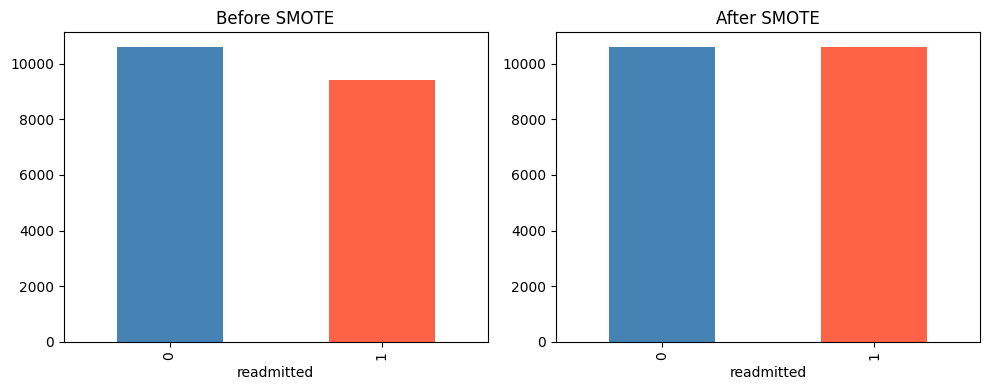

In [11]:
# Cell 5 - Handle Class Imbalance

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=ax1, color=['steelblue','tomato'])
ax1.set_title('Before SMOTE')
pd.Series(y_train_res).value_counts().plot(kind='bar', ax=ax2, color=['steelblue','tomato'])
ax2.set_title('After SMOTE')
plt.tight_layout()
plt.show()


Training Logistic Regression...
AUROC: 0.6429
              precision    recall  f1-score   support

           0       0.61      0.70      0.65      2649
           1       0.60      0.50      0.55      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.61      0.60      5000


Training Random Forest...
AUROC: 0.6274
              precision    recall  f1-score   support

           0       0.61      0.67      0.64      2649
           1       0.58      0.53      0.55      2351

    accuracy                           0.60      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.60      0.60      0.60      5000


Training XGBoost...
AUROC: 0.6362
              precision    recall  f1-score   support

           0       0.62      0.67      0.64      2649
           1       0.58      0.53      0.56      2351

    accuracy                           0.60      5000
   ma

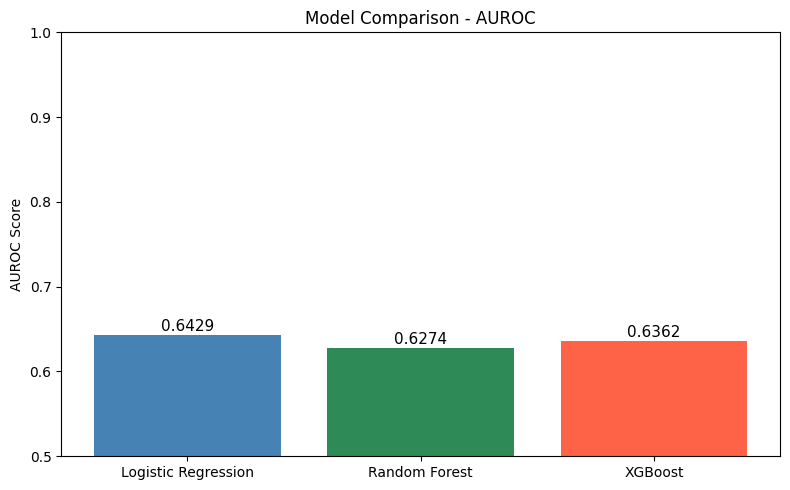


🏆 Best Model: Logistic Regression — AUROC: 0.6429


In [12]:
# Cell 6 - Model Training

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'auc': auc, 'y_pred': y_pred}
    print(f"AUROC: {auc:.4f}")
    print(classification_report(y_test, y_pred))

# Compare visually
plt.figure(figsize=(8, 5))
model_names = list(results.keys())
aucs = [results[m]['auc'] for m in model_names]
bars = plt.bar(model_names, aucs, color=['steelblue', 'seagreen', 'tomato'])
plt.ylim(0.5, 1.0)
plt.title('Model Comparison - AUROC')
plt.ylabel('AUROC Score')
for bar, auc in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{auc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

best_model_name = max(results, key=lambda x: results[x]['auc'])
print(f"\n🏆 Best Model: {best_model_name} — AUROC: {results[best_model_name]['auc']:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV AUROC:, 0.6512

Final Test AUROC: 0.6566
              precision    recall  f1-score   support

           0       0.62      0.71      0.66      2649
           1       0.61      0.51      0.55      2351

    accuracy                           0.62      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.61      0.62      0.61      5000



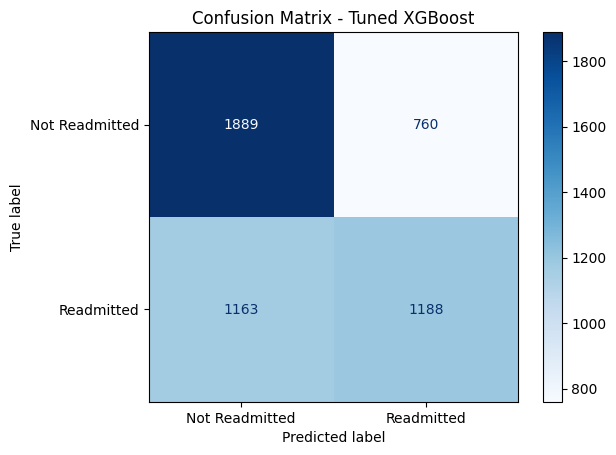

In [15]:
# Cell 7 - Hyperparameter Tuning (XGBoost)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train_res, y_train_res)

print("Best Params:", grid.best_params_)
print(f"Best CV AUROC:, {grid.best_score_:.4f}")

best_model = grid.best_estimator_

# Final evaluation
y_pred_final = best_model.predict(X_test_scaled)
y_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]
print(f"\nFinal Test AUROC: {roc_auc_score(y_test, y_proba_final):.4f}")
print(classification_report(y_test, y_pred_final))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final,
    display_labels=['Not Readmitted', 'Readmitted'], cmap='Blues')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

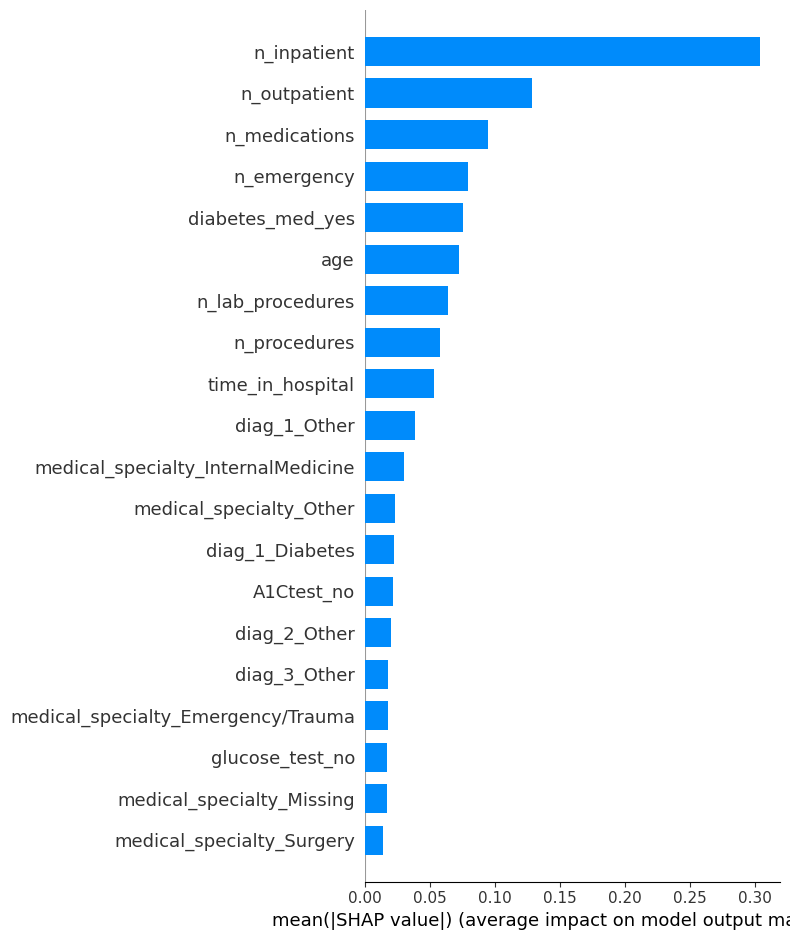

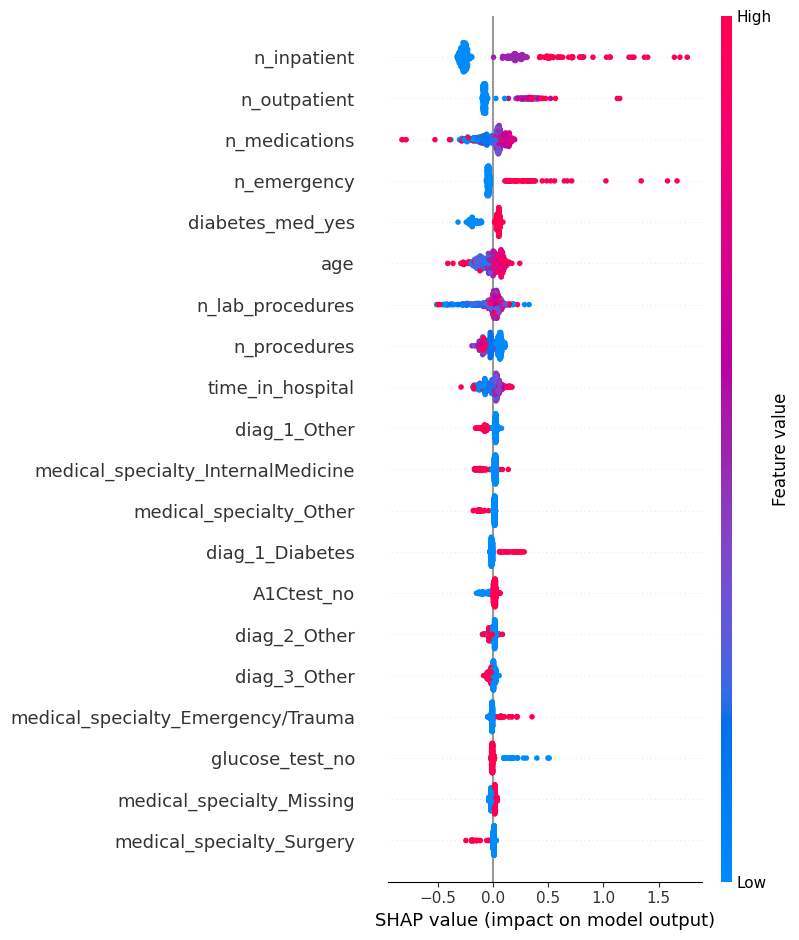


Explaining prediction for Patient #1:


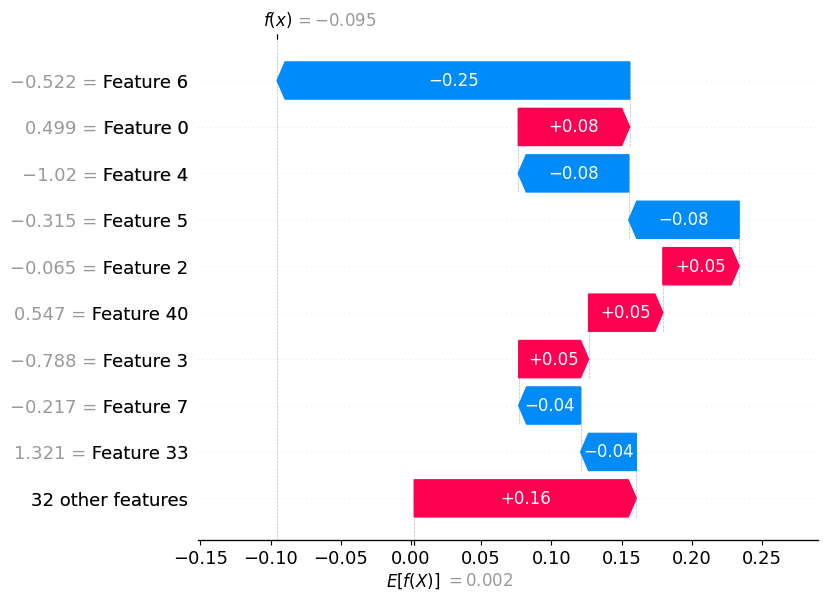

In [16]:
# Cell 8 - SHAP Explainability

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test_scaled[:500])

# Get feature names
feature_names = X.columns.tolist()

# Summary plot
shap.summary_plot(shap_values, X_test_scaled[:500],
                  feature_names=feature_names, plot_type='bar')

shap.summary_plot(shap_values, X_test_scaled[:500],
                  feature_names=feature_names)

# Single patient explanation
print("\nExplaining prediction for Patient #1:")
shap.plots.waterfall(shap_values[0])

In [17]:
# Cell 9 - Save Model

joblib.dump(best_model, '../model.pkl')
joblib.dump(scaler, '../scaler.pkl')
joblib.dump(X.columns.tolist(), '../feature_names.pkl')

print("✅ Model saved!")
print("✅ Scaler saved!")
print("✅ Feature names saved!")

✅ Model saved!
✅ Scaler saved!
✅ Feature names saved!
